In [1]:
run = "1xrtx3090-moe-balancing-aux-scale-0"

In [2]:
from pathlib import Path

run_dir = Path(f"runs/{run}")
checkpoints_dir = run_dir / "checkpoints"

checkpoint_dirs = sorted([item for item in checkpoints_dir.iterdir() if not item.is_symlink()])

In [3]:
import json

moe_routing_weights = []
moe_routing_topk_weights = []
for checkpoint_dir in checkpoint_dirs:
    meta = json.loads((checkpoint_dir / "meta.json").read_text())
    moe_routing_weights += meta["moe_routing_weights"]
    moe_routing_topk_weights += meta["moe_routing_topk_weights"]

In [4]:
layers_steps_weights = {}
layers_steps_topk_weights = {}
for step, (step_weights, step_topk_weights) in enumerate(zip(moe_routing_weights, moe_routing_topk_weights)):
    for layer, (layer_weights, layer_topk_weights) in enumerate(zip(step_weights, step_topk_weights)):
        if layer not in layers_steps_weights:
            layers_steps_weights[layer] = {}
            
        if layer not in layers_steps_topk_weights:
            layers_steps_topk_weights[layer] = {}

        layers_steps_weights[layer][step] = layer_weights
        layers_steps_topk_weights[layer][step] = layer_topk_weights


In [5]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

import numpy as np

In [6]:
plt.xkcd()

font_family = None
for f in font_manager.fontManager.ttflist:
    if "xkcd" in f.name.lower():
        font_family = f.name
        break
if font_family is not None:
    plt.rcParams['font.family'] = font_family

In [7]:
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_router_saturation(layer_number, max_yticks=12):
    layer_weights = layers_steps_weights[layer_number]
    layer_topk_weights = layers_steps_topk_weights[layer_number]

    steps = sorted(layer_weights.keys())
    weights = np.array([layer_weights[s] for s in steps])
    topk_weights = np.array([layer_topk_weights[s] for s in steps])
    n_steps, n_experts = weights.shape
    uniform = 1.0 / n_experts

    cmap = ListedColormap(["white", "tab:green", "tab:red"])
    norm = BoundaryNorm([0, uniform / 3, uniform * 2, 1.0], cmap.N)

    fig, (ax_raw, ax_topk) = plt.subplots(
        1, 2, figsize=(10, 6), dpi=100, sharey=True,
    )

    heatmap_kwargs = dict(
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    ax_raw.imshow(weights, **heatmap_kwargs)
    ax_raw.set_title("RAW ROUTING")
    ax_raw.set_ylabel("STEP")

    ax_topk.imshow(topk_weights, **heatmap_kwargs)
    ax_topk.set_title("POST TOP-K")

    for ax in (ax_raw, ax_topk):
        ax.set_xlabel("EXPERT")
        ax.set_xticks(range(n_experts))
        ax.set_xticklabels(range(n_experts))

    tick_idx = np.linspace(0, n_steps - 1, min(max_yticks, n_steps), dtype=int)
    ax_raw.set_yticks(tick_idx)
    ax_raw.set_yticklabels([steps[i] // 96 for i in tick_idx])

    fig.suptitle(f"LAYER {layer_number}")
    fig.tight_layout()
    return fig, (ax_raw, ax_topk)

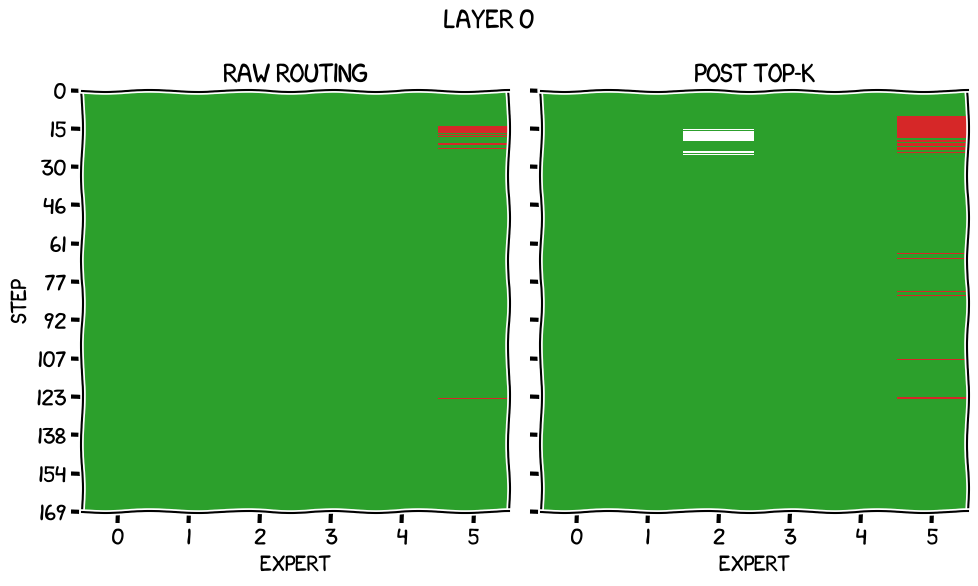

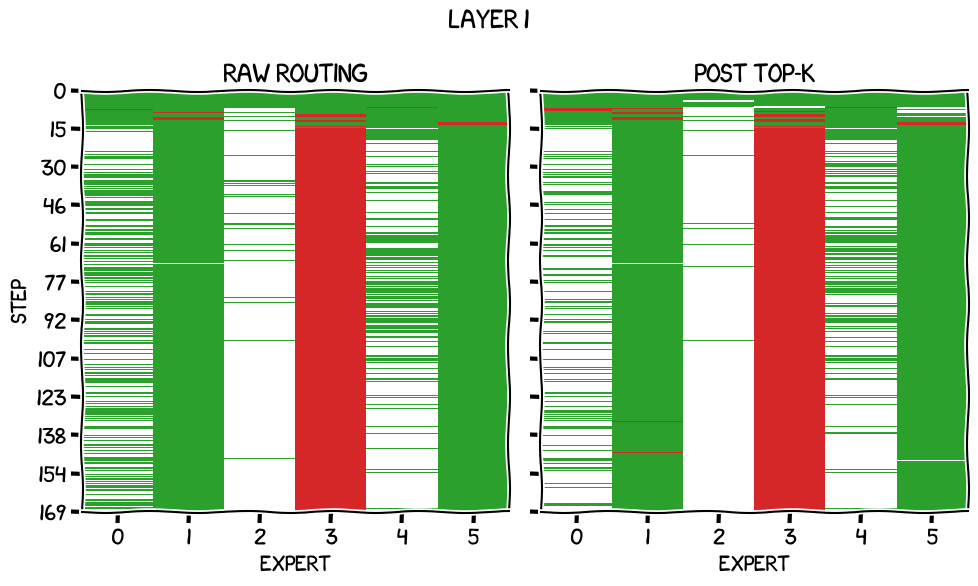

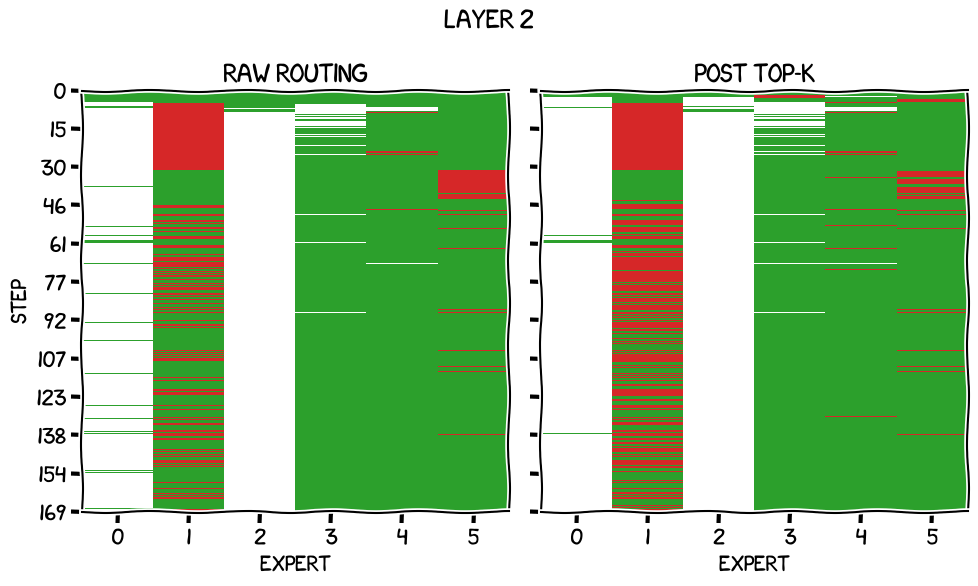

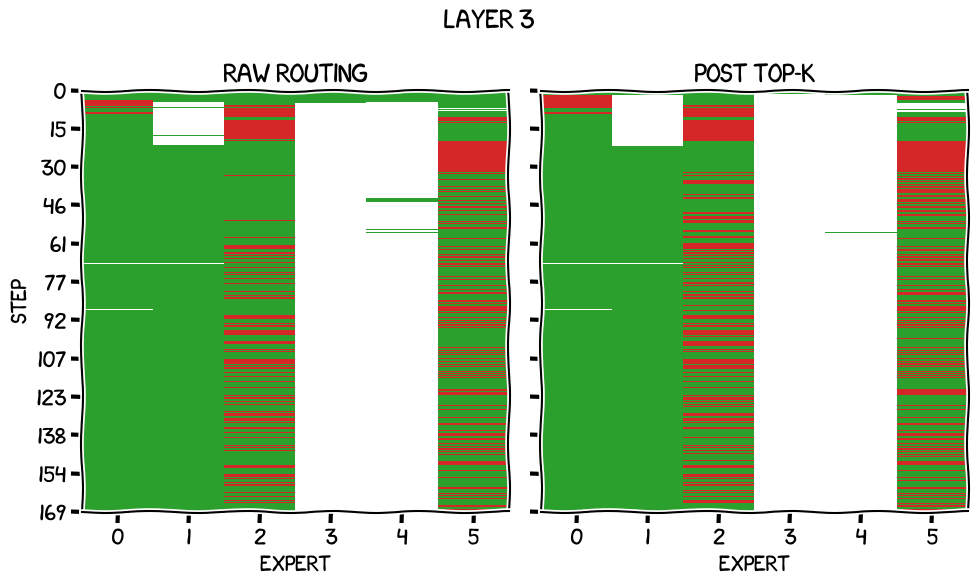

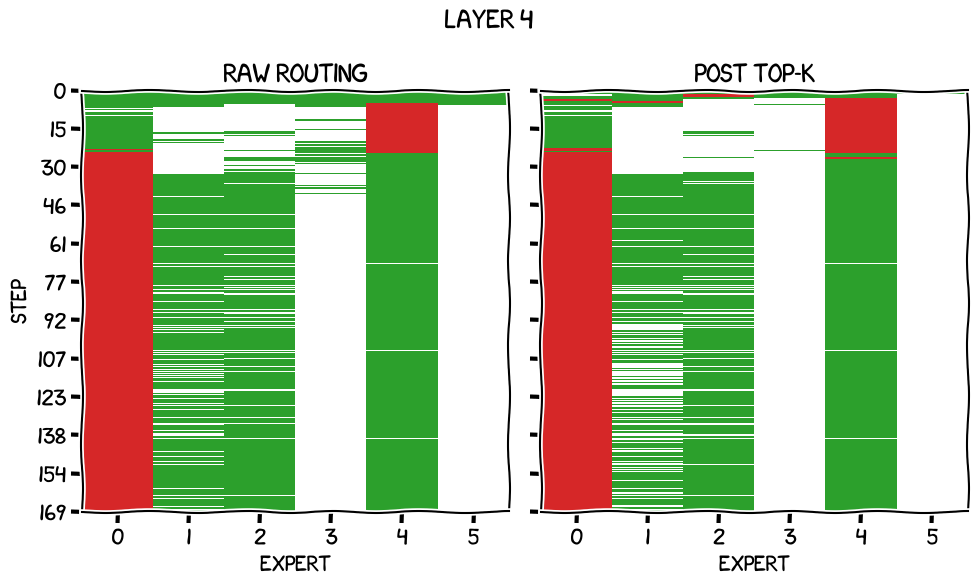

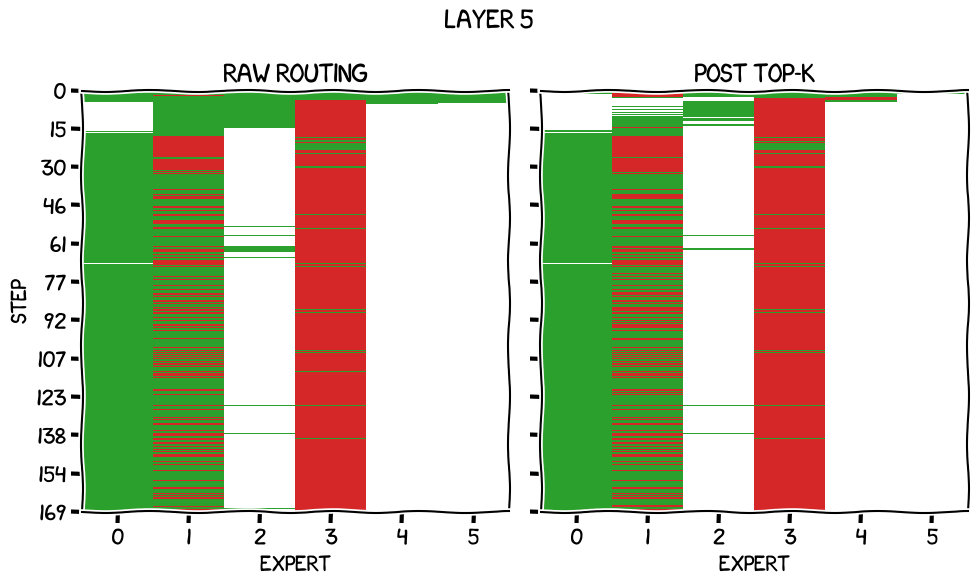

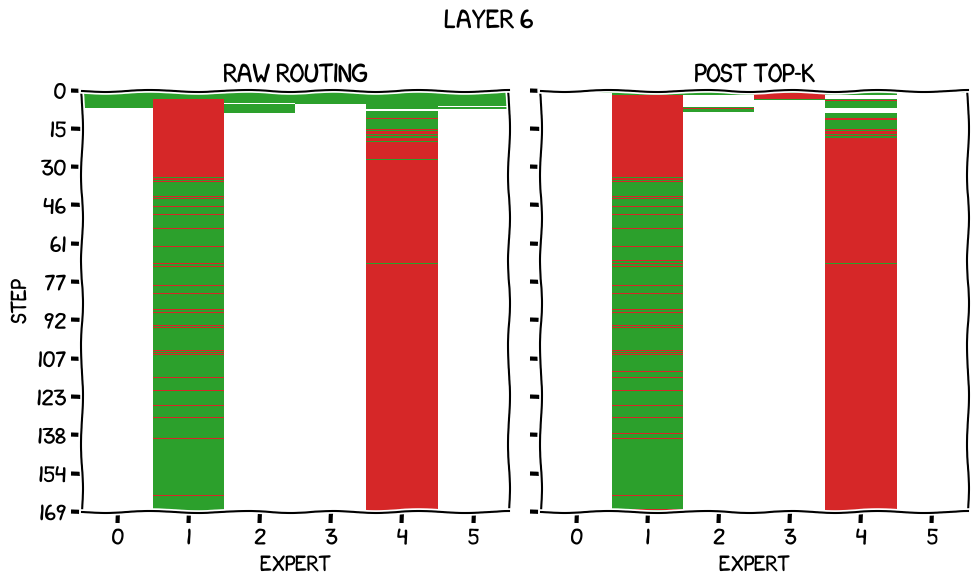

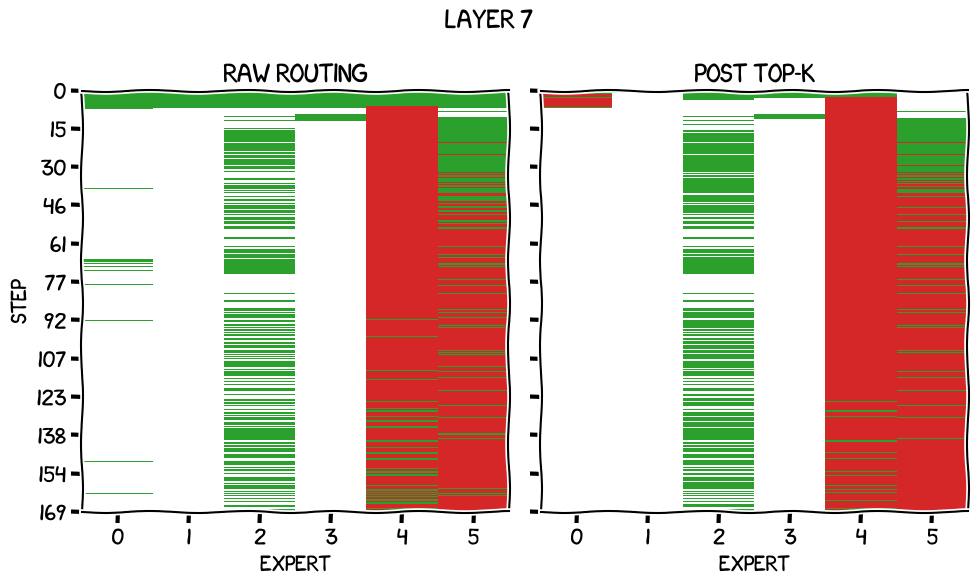

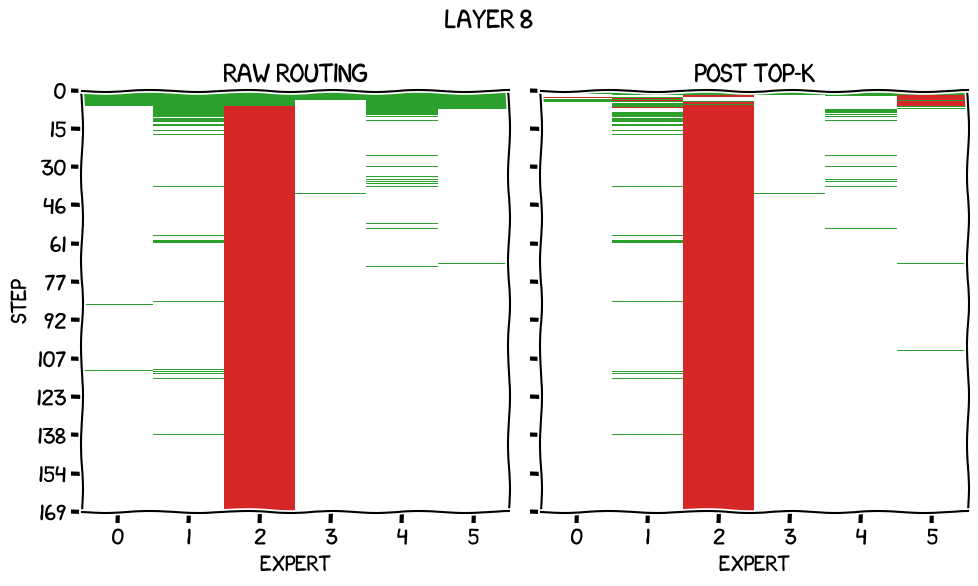

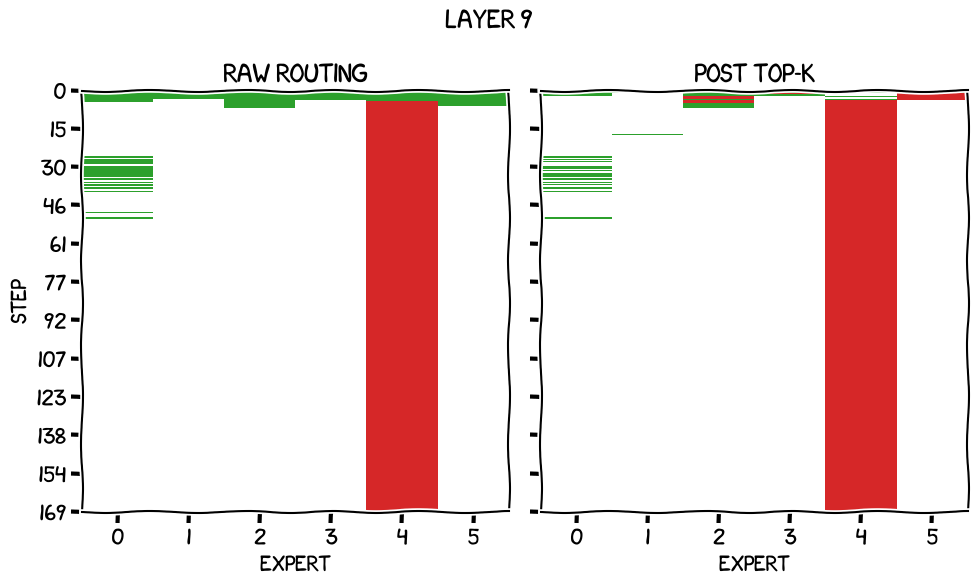

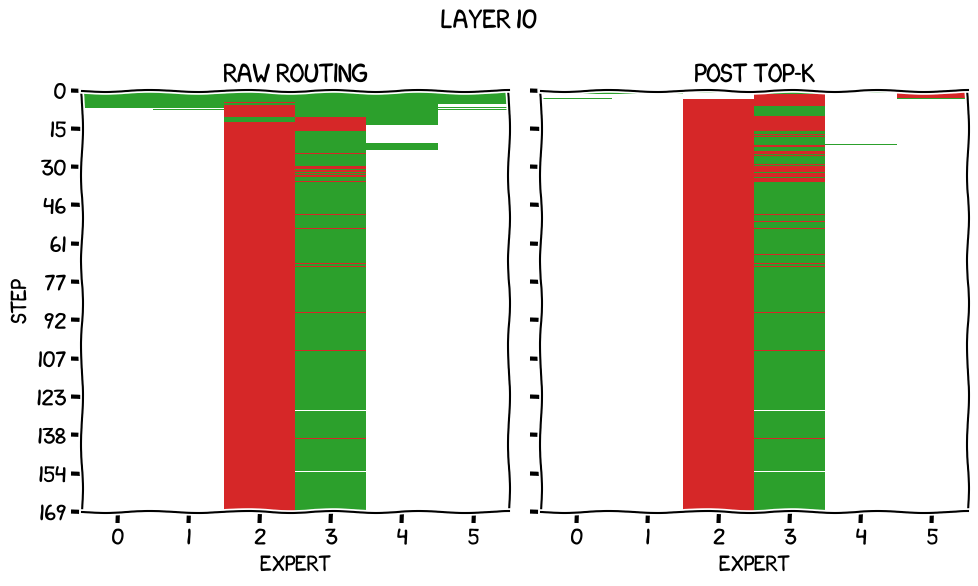

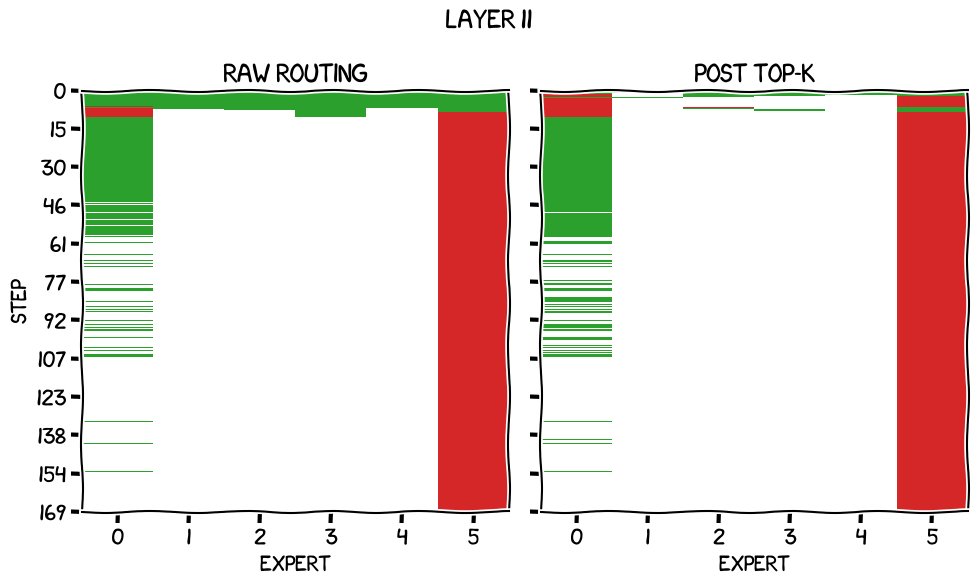

In [8]:
for layer_number in layers_steps_weights:
    fig, ax = plot_router_saturation(layer_number)
    plt.show()